# Master Thesis Benchmark Plots

This notebook reads merged JSONL benchmark files and generates comparison plots for:
- **Contraction benchmarks**: C (CPU) vs Mojo (GPU)
- **DMRG benchmarks**: C (CPU) vs Mojo (GPU)

Data files are expected in `../results/perf/` with names like:
- `_merged_contraction_timings_{nsites}_{d}_{chi_max}.jsonl`
- `_dmrg_compare/dmrg_singlesite_timings_{nsites}_{d}_{chi_max}_{num_sweeps}.jsonl`
- `_dmrg_compare/dmrg_twosite_timings_{nsites}_{d}_{chi_max}_{num_sweeps}.jsonl`

DMRG runtime plots are generated **per `num_sweeps`** (so curves do not mix different sweep counts). Additional plots show runtime vs `num_sweeps` at fixed `(nsites, chi_max)`.

In [53]:
# =========================
# 1) Imports & Configuration
# =========================
import json
import re
import statistics
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
SCRIPT_DIR = Path.cwd()
RESULTS_PERF_DIR = SCRIPT_DIR.parent / "results" / "perf" if (SCRIPT_DIR.parent / "results" / "perf").exists() else SCRIPT_DIR / ".." / "results" / "perf"
RESULTS_PERF_DIR = RESULTS_PERF_DIR.resolve()

# DMRG plots: only load merged JSONLs from `_dmrg_compare/` (clean one sweep per file).
# If False, also reads `results/perf/*.jsonl`, which are often append-heavy and contain
# multiple num_sweeps values → duplicate markers per nsites on fixed-chi_max plots.
DMRG_LOAD_COMPARE_ONLY = True

# Output directory for plots
PLOT_OUT_DIR = SCRIPT_DIR / "plots" / datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
PLOT_OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results dir: {RESULTS_PERF_DIR}")
print(f"DMRG_LOAD_COMPARE_ONLY: {DMRG_LOAD_COMPARE_ONLY}")
print(f"Plot output dir: {PLOT_OUT_DIR}")
print(f"Results dir exists: {RESULTS_PERF_DIR.exists()}")

Results dir: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/results/perf
DMRG_LOAD_COMPARE_ONLY: True
Plot output dir: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41
Results dir exists: True


In [54]:
# =========================
# 2) Data Loading Functions
# =========================

def load_jsonl(filepath: Path) -> list[dict]:
    """Load all records from a JSONL file."""
    records = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    continue
    return records


def load_contraction_benchmarks(perf_dir: Path) -> pd.DataFrame:
    """Load all contraction benchmark JSONL files into a DataFrame."""
    rows = []
    
    # Look for merged files first, then raw files
    patterns = [
        "_merged_contraction_timings_*.jsonl",
        "contraction_timings_*.jsonl",
    ]
    
    files_found = set()
    for pattern in patterns:
        for path in sorted(perf_dir.glob(pattern)):
            if path.name.startswith("_merged_"):
                # For merged files, extract params from filename
                base = path.name.replace("_merged_", "")
            else:
                base = path.name
            
            if base in files_found:
                continue
            files_found.add(base)
            
            for rec in load_jsonl(path):
                params = rec.get("params", {})
                rows.append({
                    "backend": rec.get("backend"),
                    "operation": rec.get("operation"),
                    "nsites": params.get("nsites"),
                    "d": params.get("d"),
                    "chi_max": params.get("chi_max"),
                    "time_seconds": rec.get("time_seconds"),
                    "result": rec.get("result"),
                    "runs": rec.get("runs", 1),
                    "timestamp": rec.get("timestamp"),
                    "source_file": path.name,
                })
    
    df = pd.DataFrame(rows)
    print(f"Loaded {len(df)} contraction benchmark records from {len(files_found)} file(s)")
    return df


def load_dmrg_benchmarks(perf_dir: Path, *, compare_only: bool = True) -> pd.DataFrame:
    """Load DMRG benchmark JSONL files into a DataFrame.

    compare_only=True (default): only read ``perf_dir/_dmrg_compare/`` (merged C+Mojo from
    ``merge_and_analyze_benchmarks --dmrg``). Matches JSONLs like
    ``dmrg_twosite_timings_{nsites}_{d}_{chi_max}_{num_sweeps}.jsonl`` there.

    compare_only=False: also scan ``perf_dir/`` for filenames not already loaded. Raw files
    under ``results/perf/`` may be append-only history; aggregation keeps ``num_sweeps``
    as its own dimension in the DataFrame.
    """
    rows = []

    search_dirs = [perf_dir / "_dmrg_compare"]
    if not compare_only:
        search_dirs.append(perf_dir)

    files_found = set()
    for search_dir in search_dirs:
        if not search_dir.exists():
            continue
        for path in sorted(search_dir.glob("dmrg_*_timings_*.jsonl")):
            if path.name in files_found:
                continue
            files_found.add(path.name)
            
            for rec in load_jsonl(path):
                params = rec.get("params", {})
                rows.append({
                    "backend": rec.get("backend"),
                    "operation": rec.get("operation"),
                    "nsites": params.get("nsites"),
                    "d": params.get("d"),
                    "chi_max": params.get("chi_max"),
                    "num_sweeps": params.get("num_sweeps"),
                    "maxiter_lanczos": params.get("maxiter_lanczos"),
                    "J": params.get("J"),
                    "D": params.get("D"),
                    "h": params.get("h"),
                    "tol_split": params.get("tol_split"),
                    "time_seconds": rec.get("time_seconds"),
                    "result": rec.get("result"),  # energy
                    "runs": rec.get("runs", 1),
                    "timestamp": rec.get("timestamp"),
                    "source_file": path.name,
                })
    
    df = pd.DataFrame(rows)
    src = "_dmrg_compare only" if compare_only else "_dmrg_compare + perf"
    print(f"Loaded {len(df)} DMRG benchmark records from {len(files_found)} file(s) ({src})")
    return df

In [55]:
# =========================
# 3) Aggregation Functions
# =========================

def aggregate_contraction_benchmarks(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate repeated measurements, computing mean and std."""
    if df.empty:
        return df
    
    group_cols = ["backend", "operation", "nsites", "d", "chi_max"]
    
    agg = (
        df.groupby(group_cols, dropna=False, as_index=False)
          .agg(
              mean_time_seconds=("time_seconds", "mean"),
              std_time_seconds=("time_seconds", "std"),
              median_time_seconds=("time_seconds", "median"),
              min_time_seconds=("time_seconds", "min"),
              max_time_seconds=("time_seconds", "max"),
              count=("time_seconds", "count"),
              mean_result=("result", "mean"),
          )
    )
    
    # Fill NaN std with 0 (single measurement)
    agg["std_time_seconds"] = agg["std_time_seconds"].fillna(0)
    
    return agg


def aggregate_dmrg_benchmarks(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate repeated DMRG measurements, computing mean and std."""
    if df.empty:
        return df
    
    group_cols = [
        "backend", "operation", "nsites", "d", "chi_max",
        "num_sweeps", "maxiter_lanczos", "J", "D", "h", "tol_split"
    ]
    
    agg = (
        df.groupby(group_cols, dropna=False, as_index=False)
          .agg(
              mean_time_seconds=("time_seconds", "mean"),
              std_time_seconds=("time_seconds", "std"),
              median_time_seconds=("time_seconds", "median"),
              min_time_seconds=("time_seconds", "min"),
              max_time_seconds=("time_seconds", "max"),
              count=("time_seconds", "count"),
              mean_energy=("result", "mean"),
              std_energy=("result", "std"),
          )
    )
    
    agg["std_time_seconds"] = agg["std_time_seconds"].fillna(0)
    agg["std_energy"] = agg["std_energy"].fillna(0)
    
    return agg

In [56]:
# =========================
# 4) Load Data
# =========================

# Load contraction benchmarks
contraction_df = load_contraction_benchmarks(RESULTS_PERF_DIR)
contraction_agg = aggregate_contraction_benchmarks(contraction_df)

print("\n--- Contraction Benchmark Summary ---")
print(f"Backends: {sorted(contraction_df['backend'].dropna().unique().tolist())}")
print(f"Operations: {sorted(contraction_df['operation'].dropna().unique().tolist())}")
print(f"nsites: {sorted(contraction_df['nsites'].dropna().unique().tolist())}")
print(f"chi_max: {sorted(contraction_df['chi_max'].dropna().unique().tolist())}")

display(contraction_agg.head(10))

Loaded 2351 contraction benchmark records from 63 file(s)

--- Contraction Benchmark Summary ---
Backends: ['c', 'mojo']
Operations: ['left_env_sweep', 'mps_mpo_apply', 'mps_mpo_inner', 'mps_mps']
nsites: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 26]
chi_max: [64, 128, 256, 512, 1024, 2048, 4096]


,backend,operation,nsites,d,chi_max,mean_time_seconds,std_time_seconds,median_time_seconds,min_time_seconds,max_time_seconds,count,mean_result
0,c,mps_mpo_apply,2,2,64,0.000056,0.000018,0.000046,0.000044,0.000080,9,0.444578
1,c,mps_mpo_apply,2,2,128,0.000041,0.000004,0.000042,0.000037,0.000045,9,0.444578
2,c,mps_mpo_apply,2,2,256,0.000051,0.000012,0.000047,0.000038,0.000063,9,0.444578
3,c,mps_mpo_apply,2,2,512,0.000045,0.000004,0.000041,0.000041,0.000050,9,0.444578
4,c,mps_mpo_apply,2,2,1024,0.000044,0.000009,0.000039,0.000036,0.000056,9,0.444578
5,c,mps_mpo_apply,2,2,2048,0.000043,0.000004,0.000042,0.000037,0.000047,9,0.444578
6,c,mps_mpo_apply,4,2,64,0.000108,0.000015,0.000105,0.000088,0.000127,9,0.494210
7,c,mps_mpo_apply,4,2,128,0.000111,0.000014,0.000120,0.000096,0.000125,9,0.494210
8,c,mps_mpo_apply,4,2,256,0.000109,0.000012,0.000108,0.000091,0.000122,9,0.494210
9,c,mps_mpo_apply,4,2,512,0.000112,0.000015,0.000107,0.000101,0.000137,9,0.494210


In [57]:
# Load DMRG benchmarks
dmrg_df = load_dmrg_benchmarks(RESULTS_PERF_DIR, compare_only=DMRG_LOAD_COMPARE_ONLY)
dmrg_agg = aggregate_dmrg_benchmarks(dmrg_df)

print("\n--- DMRG Benchmark Summary ---")
if not dmrg_df.empty:
    print(f"Backends: {sorted(dmrg_df['backend'].dropna().unique().tolist())}")
    print(f"Operations: {sorted(dmrg_df['operation'].dropna().unique().tolist())}")
    print(f"nsites: {sorted(dmrg_df['nsites'].dropna().unique().tolist())}")
    print(f"chi_max: {sorted(dmrg_df['chi_max'].dropna().unique().tolist())}")
    print(f"num_sweeps: {sorted(dmrg_df['num_sweeps'].dropna().unique().tolist())}")
    display(dmrg_agg.head(10))
else:
    print("No DMRG data found.")

Loaded 2568 DMRG benchmark records from 428 file(s) (_dmrg_compare only)

--- DMRG Benchmark Summary ---
Backends: ['c', 'mojo']
Operations: ['dmrg_singlesite', 'dmrg_twosite']
nsites: [2, 4, 6, 8, 10, 12, 14, 16]
chi_max: [64, 128, 256, 512, 1024, 2048]
num_sweeps: [5, 10, 15, 20]


,backend,operation,nsites,d,chi_max,num_sweeps,maxiter_lanczos,J,D,h,tol_split,mean_time_seconds,std_time_seconds,median_time_seconds,min_time_seconds,max_time_seconds,count,mean_energy,std_energy
0,c,dmrg_singlesite,2,2,64,5,25,1.0,1.0,0.0,NaN,0.000951,0.000108,0.000954,0.000841,0.001057,3,-1.0,0.0
1,c,dmrg_singlesite,2,2,64,10,25,1.0,1.0,0.0,NaN,0.004971,0.004563,0.003163,0.001589,0.010161,3,-1.0,0.0
2,c,dmrg_singlesite,2,2,64,15,25,1.0,1.0,0.0,NaN,0.003331,0.000234,0.003284,0.003125,0.003585,3,-1.0,0.0
3,c,dmrg_singlesite,2,2,64,20,25,1.0,1.0,0.0,NaN,0.009907,0.005338,0.010040,0.004356,0.018269,6,-1.0,0.0
4,c,dmrg_singlesite,2,2,128,5,25,1.0,1.0,0.0,NaN,0.001530,0.000799,0.001315,0.000861,0.002415,3,-1.0,0.0
5,c,dmrg_singlesite,2,2,128,10,25,1.0,1.0,0.0,NaN,0.002323,0.001062,0.001796,0.001627,0.003545,3,-1.0,0.0
6,c,dmrg_singlesite,2,2,128,15,25,1.0,1.0,0.0,NaN,0.003480,0.000959,0.003964,0.002376,0.004102,3,-1.0,0.0
7,c,dmrg_singlesite,2,2,128,20,25,1.0,1.0,0.0,NaN,0.003535,0.000607,0.003448,0.002715,0.004495,6,-1.0,0.0
8,c,dmrg_singlesite,2,2,256,5,25,1.0,1.0,0.0,NaN,0.001199,0.000246,0.001146,0.000984,0.001467,3,-1.0,0.0
9,c,dmrg_singlesite,2,2,256,10,25,1.0,1.0,0.0,NaN,0.001499,0.000122,0.001524,0.001367,0.001606,3,-1.0,0.0


In [58]:
# =========================
# 5) Plotting Functions
# =========================

def plot_c_vs_mojo_fixed_nsites(
    agg_df: pd.DataFrame,
    nsites: int,
    operation: str,
    use_mean: bool = True,
    logy: bool = True,
    logx: bool = True,
    save_path: Path = None,
    show: bool = True,
):
    """Plot C vs Mojo runtime vs chi_max for fixed nsites."""
    plot_df = agg_df[
        (agg_df["nsites"] == nsites) &
        (agg_df["operation"] == operation) &
        (agg_df["backend"].isin(["c", "mojo"]))
    ].copy()
    
    if plot_df.empty:
        print(f"No data for nsites={nsites}, operation={operation}")
        return
    
    ycol = "mean_time_seconds" if use_mean else "median_time_seconds"
    yerr_col = "std_time_seconds" if use_mean else None
    
    fig_size = (8.8, 5.2) if operation == "mps_mpo_inner" else (9.4, 5.6)
    fig, ax = plt.subplots(figsize=fig_size)
    
    colors = {"c": "tab:blue", "mojo": "tab:orange"}
    markers = {"c": "o", "mojo": "s"}
    labels = {"c": "C (CPU)", "mojo": "Mojo (GPU)"}
    
    # Get unique chi_max values for tick labels
    chi_max_values = sorted(plot_df["chi_max"].dropna().unique().astype(int).tolist())
    
    for backend in ["c", "mojo"]:
        bdf = plot_df[plot_df["backend"] == backend].sort_values("chi_max")
        if bdf.empty:
            continue
        
        x = bdf["chi_max"].values
        y = bdf[ycol].values
        yerr = bdf[yerr_col].values if yerr_col and yerr_col in bdf.columns else None
        
        ax.errorbar(
            x, y, yerr=yerr,
            marker=markers[backend],
            color=colors[backend],
            label=labels[backend],
            capsize=3,
            linewidth=2,
            markersize=8,
        )
    
    ax.set_xlabel("chi_max (bond dimension)", fontsize=30)
    ax.set_ylabel("Time (seconds)", fontsize=30)
    ax.set_title(f"{operation} | nsites={nsites}", fontsize=32)
    ax.legend(fontsize=20)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", which="major", labelsize=30)
    
    if logx:
        ax.set_xscale("log", base=2)
        ax.set_xticks(chi_max_values)
        ax.set_xticklabels([str(v) for v in chi_max_values])
    
    if logy:
        ax.set_yscale("log")
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    
    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_c_vs_mojo_fixed_chimax(
    agg_df: pd.DataFrame,
    chi_max: int,
    operation: str,
    use_mean: bool = True,
    logy: bool = True,
    max_nsites: int = 20,
    save_path: Path = None,
    show: bool = True,
):
    """Plot C vs Mojo runtime vs nsites for fixed chi_max."""
    plot_df = agg_df[
        (agg_df["chi_max"] == chi_max) &
        (agg_df["operation"] == operation) &
        (agg_df["backend"].isin(["c", "mojo"])) &
        (agg_df["nsites"] <= max_nsites)
    ].copy()
    
    if plot_df.empty:
        print(f"No data for chi_max={chi_max}, operation={operation}")
        return
    
    ycol = "mean_time_seconds" if use_mean else "median_time_seconds"
    yerr_col = "std_time_seconds" if use_mean else None
    
    fig_size = (8.8, 5.2) if operation == "mps_mpo_inner" else (9.4, 5.6)
    fig, ax = plt.subplots(figsize=fig_size)
    
    colors = {"c": "tab:blue", "mojo": "tab:orange"}
    markers = {"c": "o", "mojo": "s"}
    labels = {"c": "C (CPU)", "mojo": "Mojo (GPU)"}
    
    # Get unique nsites values for tick labels
    nsites_values = sorted(plot_df["nsites"].dropna().unique().astype(int).tolist())
    
    for backend in ["c", "mojo"]:
        bdf = plot_df[plot_df["backend"] == backend].sort_values("nsites")
        if bdf.empty:
            continue
        
        x = bdf["nsites"].values
        y = bdf[ycol].values
        yerr = bdf[yerr_col].values if yerr_col and yerr_col in bdf.columns else None
        
        ax.errorbar(
            x, y, yerr=yerr,
            marker=markers[backend],
            color=colors[backend],
            label=labels[backend],
            capsize=3,
            linewidth=2,
            markersize=8,
        )
    
    ax.set_xlabel("nsites (number of sites)", fontsize=30)
    ax.set_ylabel("Time (seconds)", fontsize=30)
    ax.set_title(f"{operation} | chi_max={chi_max}", fontsize=32)
    ax.legend(fontsize=20)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", which="major", labelsize=30)
    
    # Set explicit tick labels for actual nsites values
    ax.set_xticks(nsites_values)
    ax.set_xticklabels([str(v) for v in nsites_values])
    
    if logy:
        ax.set_yscale("log")
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    
    if show:
        plt.show()
    else:
        plt.close(fig)

In [ ]:
# =========================
# 6) DMRG Plotting Functions
# =========================

def _dmrg_plot_grouped_time_bars(
    plot_df: pd.DataFrame,
    category_col: str,
    *,
    title: str,
    xlabel: str,
    use_mean: bool = True,
    logy: bool = False,
    save_path: Path = None,
    show: bool = True,
) -> None:
    """Grouped bar chart: C vs Mojo mean time vs categorical ``category_col``."""
    if plot_df.empty:
        return

    ycol = "mean_time_seconds" if use_mean else "median_time_seconds"
    yerr_col = "std_time_seconds" if use_mean else None

    cat_vals = sorted(plot_df[category_col].dropna().unique().astype(int).tolist())
    if not cat_vals:
        return

    def _pair_for_cat(cat: int) -> tuple[float, float, float, float]:
        sub = plot_df[plot_df[category_col] == cat]
        rc = sub[sub["backend"] == "c"]
        rm = sub[sub["backend"] == "mojo"]
        tc = float(rc[ycol].iloc[0]) if len(rc) else float("nan")
        tm = float(rm[ycol].iloc[0]) if len(rm) else float("nan")
        ec = float(rc[yerr_col].iloc[0]) if (yerr_col and len(rc)) else 0.0
        em = float(rm[yerr_col].iloc[0]) if (yerr_col and len(rm)) else 0.0
        return tc, tm, ec, em

    heights_c = []
    heights_m = []
    err_c = []
    err_m = []
    for c in cat_vals:
        tc, tm, ec, em = _pair_for_cat(c)
        heights_c.append(tc)
        heights_m.append(tm)
        err_c.append(ec)
        err_m.append(em)

    x_pos = np.arange(len(cat_vals))
    width = 0.36

    colors = {"c": "tab:blue", "mojo": "tab:orange"}
    labels = {"c": "C (CPU)", "mojo": "Mojo (GPU)"}

    fig, ax = plt.subplots(figsize=(max(9.0, 0.45 * len(cat_vals) + 4), 5.8))

    ax.bar(
        x_pos - width / 2,
        heights_c,
        width,
        yerr=err_c if yerr_col else None,
        label=labels["c"],
        color=colors["c"],
        capsize=3,
        ecolor="0.35",
    )
    ax.bar(
        x_pos + width / 2,
        heights_m,
        width,
        yerr=err_m if yerr_col else None,
        label=labels["mojo"],
        color=colors["mojo"],
        capsize=3,
        ecolor="0.35",
    )

    ax.set_xlabel(xlabel, fontsize=30)
    ax.set_ylabel("Time (seconds)", fontsize=30)
    ax.set_title(title, fontsize=32)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in cat_vals], rotation=45 if len(cat_vals) > 10 else 0, ha="right" if len(cat_vals) > 10 else "center")
    ax.legend(fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=30)
    ax.grid(True, axis="y", alpha=0.3)

    if logy:
        ax.set_yscale("log")

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_dmrg_bar_vs_chimax(
    agg_df: pd.DataFrame,
    nsites: int,
    num_sweeps: int,
    operation: str = None,
    use_mean: bool = True,
    logy: bool = False,
    save_path: Path = None,
    show: bool = True,
) -> None:
    """Bar chart: time vs chi_max (grouped C vs Mojo) at fixed nsites and num_sweeps."""
    plot_df = agg_df[
        (agg_df["nsites"] == nsites)
        & (agg_df["num_sweeps"] == num_sweeps)
        & (agg_df["backend"].isin(["c", "mojo"]))
    ].copy()
    if operation:
        plot_df = plot_df[plot_df["operation"] == operation]
    if plot_df.empty:
        return
    op_str = operation if operation else "DMRG"
    _dmrg_plot_grouped_time_bars(
        plot_df,
        "chi_max",
        title=f"{op_str} | nsites={nsites}, num_sweeps={num_sweeps}",
        xlabel="chi_max (bond dimension)",
        use_mean=use_mean,
        logy=logy,
        save_path=save_path,
        show=show,
    )


def plot_dmrg_bar_vs_nsites(
    agg_df: pd.DataFrame,
    chi_max: int,
    num_sweeps: int,
    operation: str = None,
    use_mean: bool = True,
    logy: bool = False,
    max_nsites: int = 512,
    save_path: Path = None,
    show: bool = True,
) -> None:
    """Bar chart: time vs nsites (grouped C vs Mojo) at fixed chi_max and num_sweeps."""
    plot_df = agg_df[
        (agg_df["chi_max"] == chi_max)
        & (agg_df["num_sweeps"] == num_sweeps)
        & (agg_df["backend"].isin(["c", "mojo"]))
        & (agg_df["nsites"] <= max_nsites)
    ].copy()
    if operation:
        plot_df = plot_df[plot_df["operation"] == operation]
    if plot_df.empty:
        return
    op_str = operation if operation else "DMRG"
    _dmrg_plot_grouped_time_bars(
        plot_df,
        "nsites",
        title=f"{op_str} | chi_max={chi_max}, num_sweeps={num_sweeps}",
        xlabel="nsites (number of sites)",
        use_mean=use_mean,
        logy=logy,
        save_path=save_path,
        show=show,
    )


def plot_dmrg_bar_vs_num_sweeps(
    agg_df: pd.DataFrame,
    nsites: int,
    chi_max: int,
    operation: str = None,
    use_mean: bool = True,
    logy: bool = False,
    save_path: Path = None,
    show: bool = True,
) -> None:
    """Bar chart: time vs num_sweeps (grouped C vs Mojo) at fixed nsites and chi_max."""
    plot_df = agg_df[
        (agg_df["nsites"] == nsites)
        & (agg_df["chi_max"] == chi_max)
        & (agg_df["backend"].isin(["c", "mojo"]))
    ].copy()
    if operation:
        plot_df = plot_df[plot_df["operation"] == operation]
    if plot_df.empty:
        return
    op_str = operation if operation else "DMRG"
    _dmrg_plot_grouped_time_bars(
        plot_df,
        "num_sweeps",
        title=f"{op_str} | nsites={nsites}, chi_max={chi_max}",
        xlabel="num_sweeps",
        use_mean=use_mean,
        logy=logy,
        save_path=save_path,
        show=show,
    )


def plot_dmrg_c_vs_mojo_fixed_nsites(
    agg_df: pd.DataFrame,
    nsites: int,
    operation: str = None,
    num_sweeps: int | None = None,
    use_mean: bool = True,
    logy: bool = True,
    logx: bool = True,
    save_path: Path = None,
    show: bool = True,
):
    """Plot DMRG C vs Mojo runtime vs chi_max for fixed nsites.

    If ``num_sweeps`` is given, only that sweep count is shown (recommended when multiple
    sweep values exist in the aggregated table).
    """
    plot_df = agg_df[
        (agg_df["nsites"] == nsites) &
        (agg_df["backend"].isin(["c", "mojo"]))
    ].copy()

    if num_sweeps is not None:
        plot_df = plot_df[plot_df["num_sweeps"] == num_sweeps]

    if operation:
        plot_df = plot_df[plot_df["operation"] == operation]

    if plot_df.empty:
        sw = f", num_sweeps={num_sweeps}" if num_sweeps is not None else ""
        print(f"No DMRG data for nsites={nsites}{sw}")
        return

    ycol = "mean_time_seconds" if use_mean else "median_time_seconds"
    yerr_col = "std_time_seconds" if use_mean else None

    fig, ax = plt.subplots(figsize=(9.4, 5.6))

    colors = {"c": "tab:blue", "mojo": "tab:orange"}
    markers = {"c": "o", "mojo": "s"}
    labels = {"c": "C (CPU)", "mojo": "Mojo (GPU)"}

    chi_max_values = sorted(plot_df["chi_max"].dropna().unique().astype(int).tolist())

    for backend in ["c", "mojo"]:
        bdf = plot_df[plot_df["backend"] == backend].sort_values("chi_max")
        if bdf.empty:
            continue

        x = bdf["chi_max"].values
        y = bdf[ycol].values
        yerr = bdf[yerr_col].values if yerr_col and yerr_col in bdf.columns else None

        ax.errorbar(
            x, y, yerr=yerr,
            marker=markers[backend],
            color=colors[backend],
            label=labels[backend],
            capsize=3,
            linewidth=2,
            markersize=8,
        )

    op_str = operation if operation else "DMRG"
    sw_title = f", num_sweeps={num_sweeps}" if num_sweeps is not None else ""
    ax.set_xlabel("chi_max (bond dimension)", fontsize=14)
    ax.set_ylabel("Time (seconds)", fontsize=14)
    ax.set_title(f"{op_str} | nsites={nsites}{sw_title}", fontsize=16)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", which="major", labelsize=12)

    if logx:
        ax.set_xscale("log", base=2)
        ax.set_xticks(chi_max_values)
        ax.set_xticklabels([str(v) for v in chi_max_values])

    if logy:
        ax.set_yscale("log")

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_dmrg_c_vs_mojo_fixed_chimax(
    agg_df: pd.DataFrame,
    chi_max: int,
    operation: str = None,
    num_sweeps: int | None = None,
    use_mean: bool = True,
    logy: bool = True,
    max_nsites: int = 20,
    save_path: Path = None,
    show: bool = True,
):
    """Plot DMRG C vs Mojo runtime vs nsites for fixed chi_max.

    If ``num_sweeps`` is given, only that sweep count is shown.
    """
    plot_df = agg_df[
        (agg_df["chi_max"] == chi_max) &
        (agg_df["backend"].isin(["c", "mojo"])) &
        (agg_df["nsites"] <= max_nsites)
    ].copy()

    if num_sweeps is not None:
        plot_df = plot_df[plot_df["num_sweeps"] == num_sweeps]

    if operation:
        plot_df = plot_df[plot_df["operation"] == operation]

    if plot_df.empty:
        sw = f", num_sweeps={num_sweeps}" if num_sweeps is not None else ""
        print(f"No DMRG data for chi_max={chi_max}{sw}")
        return

    ycol = "mean_time_seconds" if use_mean else "median_time_seconds"
    yerr_col = "std_time_seconds" if use_mean else None

    fig, ax = plt.subplots(figsize=(9.4, 5.6))

    colors = {"c": "tab:blue", "mojo": "tab:orange"}
    markers = {"c": "o", "mojo": "s"}
    labels = {"c": "C (CPU)", "mojo": "Mojo (GPU)"}

    nsites_values = sorted(plot_df["nsites"].dropna().unique().astype(int).tolist())

    for backend in ["c", "mojo"]:
        bdf = plot_df[plot_df["backend"] == backend].sort_values("nsites")
        if bdf.empty:
            continue

        x = bdf["nsites"].values
        y = bdf[ycol].values
        yerr = bdf[yerr_col].values if yerr_col and yerr_col in bdf.columns else None

        ax.errorbar(
            x, y, yerr=yerr,
            marker=markers[backend],
            color=colors[backend],
            label=labels[backend],
            capsize=3,
            linewidth=2,
            markersize=8,
        )

    op_str = operation if operation else "DMRG"
    sw_title = f", num_sweeps={num_sweeps}" if num_sweeps is not None else ""
    ax.set_xlabel("nsites (number of sites)", fontsize=14)
    ax.set_ylabel("Time (seconds)", fontsize=14)
    ax.set_title(f"{op_str} | chi_max={chi_max}{sw_title}", fontsize=16)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", which="major", labelsize=12)

    ax.set_xticks(nsites_values)
    ax.set_xticklabels([str(v) for v in nsites_values])

    if logy:
        ax.set_yscale("log")

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_dmrg_c_vs_mojo_vs_num_sweeps(
    agg_df: pd.DataFrame,
    nsites: int,
    chi_max: int,
    operation: str = None,
    use_mean: bool = True,
    logy: bool = True,
    save_path: Path = None,
    show: bool = True,
):
    """Plot DMRG C vs Mojo runtime vs num_sweeps for fixed nsites and chi_max."""
    plot_df = agg_df[
        (agg_df["nsites"] == nsites) &
        (agg_df["chi_max"] == chi_max) &
        (agg_df["backend"].isin(["c", "mojo"]))
    ].copy()

    if operation:
        plot_df = plot_df[plot_df["operation"] == operation]

    if plot_df.empty:
        print(f"No DMRG data for nsites={nsites}, chi_max={chi_max}")
        return

    ycol = "mean_time_seconds" if use_mean else "median_time_seconds"
    yerr_col = "std_time_seconds" if use_mean else None

    fig, ax = plt.subplots(figsize=(9.4, 5.6))

    colors = {"c": "tab:blue", "mojo": "tab:orange"}
    markers = {"c": "o", "mojo": "s"}
    labels = {"c": "C (CPU)", "mojo": "Mojo (GPU)"}

    sweep_values = sorted(plot_df["num_sweeps"].dropna().unique().astype(int).tolist())

    for backend in ["c", "mojo"]:
        bdf = plot_df[plot_df["backend"] == backend].sort_values("num_sweeps")
        if bdf.empty:
            continue

        x = bdf["num_sweeps"].values
        y = bdf[ycol].values
        yerr = bdf[yerr_col].values if yerr_col and yerr_col in bdf.columns else None

        ax.errorbar(
            x, y, yerr=yerr,
            marker=markers[backend],
            color=colors[backend],
            label=labels[backend],
            capsize=3,
            linewidth=2,
            markersize=8,
        )

    op_str = operation if operation else "DMRG"
    ax.set_xlabel("num_sweeps", fontsize=14)
    ax.set_ylabel("Time (seconds)", fontsize=14)
    ax.set_title(f"{op_str} | nsites={nsites}, chi_max={chi_max}", fontsize=16)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", which="major", labelsize=12)

    ax.set_xticks(sweep_values)
    ax.set_xticklabels([str(v) for v in sweep_values])

    if logy:
        ax.set_yscale("log")

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)


In [60]:
# =========================
# 7) Generate Contraction Plots
# =========================

NSITES_VALUES = sorted(contraction_agg["nsites"].dropna().unique().astype(int).tolist())
CHI_VALUES = sorted(contraction_agg["chi_max"].dropna().unique().astype(int).tolist())
OPERATIONS = sorted(contraction_agg["operation"].dropna().unique().tolist())

# Filter to common operations
PLOT_OPERATIONS = [op for op in ["mps_mpo_inner", "mps_mpo_apply", "mps_mps"] if op in OPERATIONS]

print(f"Plotting contraction benchmarks:")
print(f"  nsites: {NSITES_VALUES}")
print(f"  chi_max: {CHI_VALUES}")
print(f"  operations: {PLOT_OPERATIONS}")

CONTRACTION_PLOT_DIR = PLOT_OUT_DIR / "contractions"
CONTRACTION_PLOT_DIR.mkdir(parents=True, exist_ok=True)

for operation in PLOT_OPERATIONS:
    # Fixed nsites plots
    for nsites in NSITES_VALUES:
        plot_c_vs_mojo_fixed_nsites(
            contraction_agg,
            nsites=nsites,
            operation=operation,
            save_path=CONTRACTION_PLOT_DIR / f"{operation}_nsites_{nsites}.png",
            show=False,
        )
    
    # Fixed chi_max plots
    for chi_max in CHI_VALUES:
        plot_c_vs_mojo_fixed_chimax(
            contraction_agg,
            chi_max=chi_max,
            operation=operation,
            save_path=CONTRACTION_PLOT_DIR / f"{operation}_chimax_{chi_max}.png",
            show=False,
        )

print(f"\nContraction plots saved to: {CONTRACTION_PLOT_DIR}")

Plotting contraction benchmarks:
  nsites: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 26]
  chi_max: [64, 128, 256, 512, 1024, 2048, 4096]
  operations: ['mps_mpo_inner', 'mps_mpo_apply', 'mps_mps']
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/contractions/mps_mpo_inner_nsites_2.png
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/contractions/mps_mpo_inner_nsites_4.png
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/contractions/mps_mpo_inner_nsites_6.png
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/contractions/mps_mpo_inner_nsites_8.png
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/contractions/mps_mpo_inner_nsites_10.png
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/contractions/mps_mpo_inner_nsi

In [61]:
# =========================
# 8) Generate DMRG Plots
# =========================

if not dmrg_agg.empty:
    DMRG_NSITES_VALUES = sorted(dmrg_agg["nsites"].dropna().unique().astype(int).tolist())
    DMRG_CHI_VALUES = sorted(dmrg_agg["chi_max"].dropna().unique().astype(int).tolist())
    DMRG_NUM_SWEEPS_VALUES = sorted(dmrg_agg["num_sweeps"].dropna().unique().astype(int).tolist())
    DMRG_OPERATIONS = sorted(dmrg_agg["operation"].dropna().unique().tolist())

    print(f"Plotting DMRG benchmarks:")
    print(f"  nsites: {DMRG_NSITES_VALUES}")
    print(f"  chi_max: {DMRG_CHI_VALUES}")
    print(f"  num_sweeps: {DMRG_NUM_SWEEPS_VALUES}")
    print(f"  operations: {DMRG_OPERATIONS}")

    DMRG_PLOT_DIR = PLOT_OUT_DIR / "dmrg"
    DMRG_PLOT_DIR.mkdir(parents=True, exist_ok=True)

    DMRG_BAR_DIR = DMRG_PLOT_DIR / "bars"
    DMRG_BAR_DIR.mkdir(parents=True, exist_ok=True)

    for operation in DMRG_OPERATIONS:
        for num_sweeps in DMRG_NUM_SWEEPS_VALUES:
            # Fixed nsites → vary chi_max (one curve per backend)
            for nsites in DMRG_NSITES_VALUES:
                plot_dmrg_c_vs_mojo_fixed_nsites(
                    dmrg_agg,
                    nsites=nsites,
                    operation=operation,
                    num_sweeps=num_sweeps,
                    save_path=DMRG_PLOT_DIR / f"{operation}_nsites_{nsites}_sweeps_{num_sweeps}.png",
                    show=False,
                )

            # Fixed chi_max → vary nsites
            for chi_max in DMRG_CHI_VALUES:
                plot_dmrg_c_vs_mojo_fixed_chimax(
                    dmrg_agg,
                    chi_max=chi_max,
                    operation=operation,
                    num_sweeps=num_sweeps,
                    save_path=DMRG_PLOT_DIR / f"{operation}_chimax_{chi_max}_sweeps_{num_sweeps}.png",
                    show=False,
                )

            # --- Grouped bar charts (same slices as line plots) ---
            max_ns_bar = int(dmrg_agg["nsites"].dropna().max()) + 1 if not dmrg_agg["nsites"].dropna().empty else 512
            for nsites in DMRG_NSITES_VALUES:
                plot_dmrg_bar_vs_chimax(
                    dmrg_agg,
                    nsites=nsites,
                    num_sweeps=num_sweeps,
                    operation=operation,
                    logy=False,
                    save_path=DMRG_BAR_DIR / f"{operation}_bar_chimax_nsites_{nsites}_sweeps_{num_sweeps}.png",
                    show=False,
                )

            for chi_max in DMRG_CHI_VALUES:
                plot_dmrg_bar_vs_nsites(
                    dmrg_agg,
                    chi_max=chi_max,
                    num_sweeps=num_sweeps,
                    operation=operation,
                    max_nsites=max_ns_bar,
                    logy=False,
                    save_path=DMRG_BAR_DIR / f"{operation}_bar_nsites_chimax_{chi_max}_sweeps_{num_sweeps}.png",
                    show=False,
                )

        # Runtime vs num_sweeps at each (nsites, chi_max) that appears in the data
        for nsites in DMRG_NSITES_VALUES:
            for chi_max in DMRG_CHI_VALUES:
                has_pair = not dmrg_agg.loc[
                    (dmrg_agg["operation"] == operation)
                    & (dmrg_agg["nsites"] == nsites)
                    & (dmrg_agg["chi_max"] == chi_max)
                ].empty
                if not has_pair:
                    continue
                plot_dmrg_c_vs_mojo_vs_num_sweeps(
                    dmrg_agg,
                    nsites=nsites,
                    chi_max=chi_max,
                    operation=operation,
                    save_path=DMRG_PLOT_DIR / f"{operation}_nsites_{nsites}_chimax_{chi_max}_vs_sweeps.png",
                    show=False,
                )
                plot_dmrg_bar_vs_num_sweeps(
                    dmrg_agg,
                    nsites=nsites,
                    chi_max=chi_max,
                    operation=operation,
                    logy=False,
                    save_path=DMRG_BAR_DIR / f"{operation}_bar_sweeps_nsites_{nsites}_chimax_{chi_max}.png",
                    show=False,
                )

    print(f"\nDMRG line plots: {DMRG_PLOT_DIR}")
    print(f"DMRG bar charts: {DMRG_BAR_DIR}")
else:
    print("No DMRG data to plot.")


Plotting DMRG benchmarks:
  nsites: [2, 4, 6, 8, 10, 12, 14, 16]
  chi_max: [64, 128, 256, 512, 1024, 2048]
  num_sweeps: [5, 10, 15, 20]
  operations: ['dmrg_singlesite', 'dmrg_twosite']
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/dmrg/dmrg_singlesite_nsites_2_sweeps_5.png
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/dmrg/dmrg_singlesite_nsites_4_sweeps_5.png
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/dmrg/dmrg_singlesite_nsites_6_sweeps_5.png
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/dmrg/dmrg_singlesite_nsites_8_sweeps_5.png
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/dmrg/dmrg_singlesite_nsites_10_sweeps_5.png
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/dmrg/dmrg_singlesite

In [62]:
# =========================
# 9) Export Aggregated Data to CSV
# =========================

contraction_agg.to_csv(PLOT_OUT_DIR / "contraction_aggregated.csv", index=False)
print(f"Saved: {PLOT_OUT_DIR / 'contraction_aggregated.csv'}")

if not dmrg_agg.empty:
    dmrg_agg.to_csv(PLOT_OUT_DIR / "dmrg_aggregated.csv", index=False)
    print(f"Saved: {PLOT_OUT_DIR / 'dmrg_aggregated.csv'}")

print(f"\nAll outputs saved to: {PLOT_OUT_DIR}")

Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/contraction_aggregated.csv
Saved: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41/dmrg_aggregated.csv

All outputs saved to: /home/batu/Master_Thesis/chemtensor_mojo/chemtensor_mojo/tools/plots/2026-05-15_14-31-41


Example plot: mps_mpo_inner at nsites=2


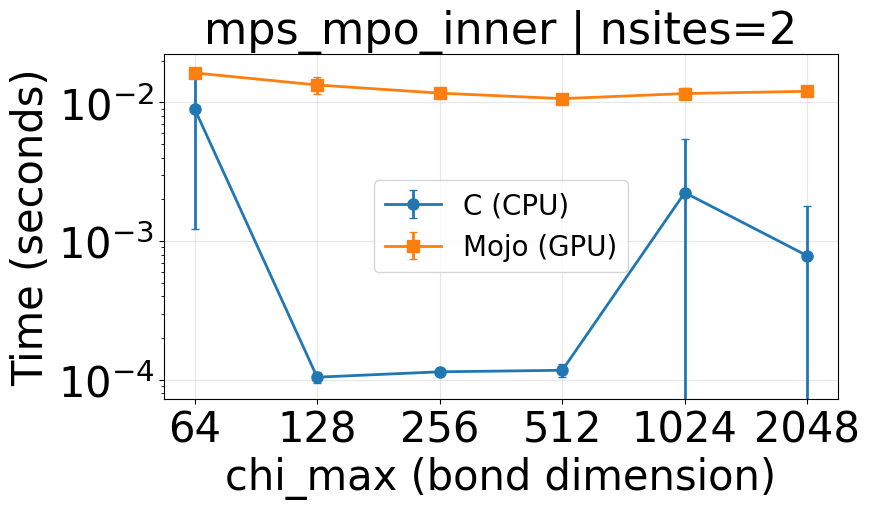

In [63]:
# =========================
# 10) Interactive Single Plot (Example)
# =========================

# Example: Show a single plot interactively
if not contraction_agg.empty and len(NSITES_VALUES) > 0 and len(PLOT_OPERATIONS) > 0:
    example_nsites = NSITES_VALUES[0]
    example_op = PLOT_OPERATIONS[0]
    print(f"Example plot: {example_op} at nsites={example_nsites}")
    plot_c_vs_mojo_fixed_nsites(
        contraction_agg,
        nsites=example_nsites,
        operation=example_op,
        show=True,
    )

In [64]:
# =========================
# 11) Speedup Summary Table
# =========================

def compute_speedup_table(agg_df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    """Compute C/Mojo speedup for each configuration."""
    rows = []
    
    for name, group in agg_df.groupby(group_cols):
        c_row = group[group["backend"] == "c"]
        mojo_row = group[group["backend"] == "mojo"]
        
        if c_row.empty or mojo_row.empty:
            continue
        
        c_time = c_row["mean_time_seconds"].values[0]
        mojo_time = mojo_row["mean_time_seconds"].values[0]
        c_std = c_row["std_time_seconds"].values[0]
        mojo_std = mojo_row["std_time_seconds"].values[0]
        
        if mojo_time > 0:
            speedup = c_time / mojo_time
        else:
            speedup = float('nan')
        
        row = dict(zip(group_cols, name if isinstance(name, tuple) else [name]))
        row.update({
            "c_time": c_time,
            "c_std": c_std,
            "mojo_time": mojo_time,
            "mojo_std": mojo_std,
            "speedup": speedup,
            "mojo_faster": speedup > 1,
        })
        rows.append(row)
    
    return pd.DataFrame(rows)

# Contraction speedup
if not contraction_agg.empty:
    speedup_df = compute_speedup_table(contraction_agg, ["operation", "nsites", "chi_max"])
    print("\n--- Contraction Speedup Summary ---")
    print(f"Mojo faster in {speedup_df['mojo_faster'].sum()} / {len(speedup_df)} cases")
    display(speedup_df.sort_values("speedup", ascending=False).head(20))


--- Contraction Speedup Summary ---
Mojo faster in 89 / 183 cases


,operation,nsites,chi_max,c_time,c_std,mojo_time,mojo_std,speedup,mojo_faster
176,mps_mps,20,64,0.648663,0.027428,0.003704,0.000698,175.112684,True
177,mps_mps,20,128,0.690799,0.019065,0.004459,0.000928,154.935501,True
170,mps_mps,18,64,0.508746,0.020019,0.003623,0.000250,140.420232,True
171,mps_mps,18,128,0.504305,0.015596,0.004445,0.000729,113.455461,True
56,mps_mpo_apply,20,256,0.646371,0.023495,0.005718,0.000406,113.049893,True
159,mps_mps,14,128,0.214049,0.004305,0.001902,0.000384,112.524452,True
164,mps_mps,16,64,0.353925,0.004889,0.003295,0.000421,107.422357,True
167,mps_mps,16,512,0.337916,0.012851,0.003382,0.000084,99.921202,True
166,mps_mps,16,256,0.370540,0.014821,0.003726,0.000443,99.441591,True
168,mps_mps,16,1024,0.366534,0.034405,0.003692,0.000833,99.286092,True


In [65]:
# DMRG speedup
if not dmrg_agg.empty:
    dmrg_speedup_df = compute_speedup_table(dmrg_agg, ["operation", "nsites", "chi_max", "num_sweeps"])
    print("\n--- DMRG Speedup Summary ---")
    print(f"Mojo faster in {dmrg_speedup_df['mojo_faster'].sum()} / {len(dmrg_speedup_df)} cases")
    display(dmrg_speedup_df.sort_values("speedup", ascending=False).head(20))


--- DMRG Speedup Summary ---
Mojo faster in 104 / 344 cases


,operation,nsites,chi_max,num_sweeps,c_time,c_std,mojo_time,mojo_std,speedup,mojo_faster
144,dmrg_singlesite,14,64,5,85.316912,1.190464,1.712660,0.023413,49.815441,True
341,dmrg_twosite,16,128,20,491.489993,1.985549,10.108371,0.128800,48.622079,True
340,dmrg_twosite,16,64,20,489.298331,1.865014,10.097812,0.087490,48.455877,True
343,dmrg_twosite,16,512,20,485.036286,3.424912,10.069450,0.113020,48.169094,True
342,dmrg_twosite,16,256,20,485.678261,2.127095,10.273932,0.170774,47.272871,True
316,dmrg_twosite,14,64,5,56.095964,0.790780,1.679602,0.014249,33.398374,True
152,dmrg_singlesite,14,256,5,57.070912,0.444519,1.712057,0.010150,33.334702,True
148,dmrg_singlesite,14,128,5,56.507683,0.390364,1.740103,0.007258,32.473766,True
160,dmrg_singlesite,14,1024,5,54.466180,0.367289,1.706742,0.007227,31.912371,True
324,dmrg_twosite,14,256,5,50.463050,0.683326,1.676617,0.013487,30.098147,True
